# 02 — Exploratory Data Analysis
Explore the raw data to understand distributions, correlations, and position-specific patterns.

**Prerequisite:** Run notebook 01 first to populate `data/raw/`.

Loads directly from parquet cache — no dependency on notebook 03.

Key questions:
- Which stats correlate most with next-year PPR output?
- How do age curves differ by position?
- How predictive is target share / snap % on its own?
- How consistent is year-over-year fantasy production?

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.fetchers.nfl_fetcher import fetch_seasonal_stats, fetch_rosters

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 40)
%matplotlib inline

In [2]:
# Load seasonal stats from parquet cache (populated by notebook 01)
seasonal = fetch_seasonal_stats()

# Load roster/ID map and compute age at each season
rosters = fetch_rosters()
rosters['birth_date_dt'] = pd.to_datetime(rosters['birth_date'], errors='coerce')

# Join position, age, and name from rosters onto seasonal stats
df = seasonal.merge(
    rosters[['player_id', 'birth_date_dt', 'name', 'position']].drop_duplicates('player_id'),
    on='player_id', how='left'
)
df['season_start'] = pd.to_datetime(df['season'].astype(str) + '-09-01')
df['age_at_season'] = ((df['season_start'] - df['birth_date_dt']).dt.days / 365.25).round(1)
df.drop(columns=['birth_date_dt', 'season_start'], inplace=True)

if 'full_name' not in df.columns:
    df = df.rename(columns={'name': 'full_name'})

print(f'Shape: {df.shape}')
print(f'Position coverage: {df["position"].notna().mean():.1%}')
df.head(3)

  [1/13] 2012 — loaded from checkpoint
  [2/13] 2013 — loaded from checkpoint
  [3/13] 2014 — loaded from checkpoint
  [4/13] 2015 — loaded from checkpoint
  [5/13] 2016 — loaded from checkpoint
  [6/13] 2017 — loaded from checkpoint
  [7/13] 2018 — loaded from checkpoint
  [8/13] 2019 — loaded from checkpoint
  [9/13] 2020 — loaded from checkpoint
  [10/13] 2021 — loaded from checkpoint
  [11/13] 2022 — loaded from checkpoint
  [12/13] 2023 — loaded from checkpoint
  [13/13] 2024 — loaded from checkpoint
Combined seasonal stats: 7870 rows saved to /home/ruppdj/claude_testing/fantasy_football/src/fetchers/../../data/raw/seasonal_stats.parquet
Loading rosters from cache: /home/ruppdj/claude_testing/fantasy_football/src/fetchers/../../data/raw/rosters.parquet
Shape: (7870, 61)
Position coverage: 93.3%


,player_id,season,season_type,completions,attempts,passing_yards,passing_tds,interceptions,sacks,sack_yards,sack_fumbles,sack_fumbles_lost,passing_air_yards,passing_yards_after_catch,passing_first_downs,passing_epa,passing_2pt_conversions,pacr,dakota,carries,...,wopr_x,special_teams_tds,fantasy_points,fantasy_points_ppr,games,tgt_sh,ay_sh,yac_sh,wopr_y,ry_sh,rtd_sh,rfd_sh,rtdfd_sh,dom,w8dom,yptmpa,ppr_sh,full_name,position,age_at_season
0,00-0000865,2012,REG,45,70,475.0,1,4.0,3.0,12.0,1,0,663.0,257.0,22.0,-1.646032,0,1.429991,0.160617,0,...,0.000000,0.0,15.0,15.0,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.119048,Charlie Batch,QB,37.7
1,00-0004541,2012,REG,0,0,0.0,0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.000000,0,0.000000,0.000000,0,...,0.920142,0.0,19.7,27.7,9,0.041270,0.050905,0.010084,0.102628,0.032683,0.086957,0.041667,0.048951,0.059820,0.043537,0.244444,0.030938,Donald Driver,WR,37.6
2,00-0006101,2012,REG,0,0,0.0,0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.000000,0,0.000000,0.000000,0,...,7.022350,0.0,141.0,234.0,16,0.201626,0.192846,0.122271,0.456716,0.197076,0.250000,0.264228,0.262590,0.223538,0.207661,1.512195,0.148255,Tony Gonzalez,TE,36.5


## 1. Dataset Overview

In [3]:
print('Seasons:', sorted(df['season'].unique()))
print('\nPosition counts:')
print(df['position'].value_counts())
print('\nMissing value rates (top columns):')
null_rates = df.isna().mean().sort_values(ascending=False)
print(null_rates[null_rates > 0].head(15))

Seasons: [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

Position counts:
WR    2733
RB    2083
TE    1553
QB     974
Name: position, dtype: int64

Missing value rates (top columns):
age_at_season    0.066963
position         0.066963
full_name        0.066963
w8dom            0.034816
dom              0.034816
rtd_sh           0.034816
dtype: float64


Looks like there are some players with a had full of yards that dont match which is fine. 

In [4]:
df.describe()

,season,completions,attempts,passing_yards,passing_tds,interceptions,sacks,sack_yards,sack_fumbles,sack_fumbles_lost,passing_air_yards,passing_yards_after_catch,passing_first_downs,passing_epa,passing_2pt_conversions,pacr,dakota,carries,rushing_yards,rushing_tds,...,target_share,air_yards_share,wopr_x,special_teams_tds,fantasy_points,fantasy_points_ppr,games,tgt_sh,ay_sh,yac_sh,wopr_y,ry_sh,rtd_sh,rfd_sh,rtdfd_sh,dom,w8dom,yptmpa,ppr_sh,age_at_season
count,7870.000000,7870.000000,7870.000000,7870.000000,7870.000000,7870.000000,7870.000000,7870.000000,7870.000000,7870.000000,7870.000000,7870.000000,7870.000000,7870.000000,7870.000000,7870.000000,7870.000000,7870.000000,7870.000000,7870.000000,...,7870.000000,7870.000000,7870.000000,7870.000000,7870.000000,7870.000000,7870.000000,7870.000000,7870.000000,7870.000000,7870.000000,7870.000000,7596.000000,7870.000000,7870.000000,7596.000000,7596.000000,7870.000000,7870.000000,7343.000000
mean,2018.061372,18.901144,29.774841,212.886277,1.323126,0.711563,2.050064,13.546379,0.299365,0.142694,241.466328,98.258196,10.278907,1.207856,0.057687,0.971068,0.090802,23.004574,98.349555,0.733164,...,0.861753,0.861753,1.895858,0.039136,55.542821,74.443710,8.573443,0.073716,0.072816,0.075077,0.168826,0.073816,0.076536,0.074127,0.074252,0.076026,0.075719,0.525982,0.076545,26.360833
std,3.728616,71.492408,111.225991,810.389748,5.388990,2.675609,7.665622,51.041618,1.204299,0.640160,906.682022,376.439374,39.340346,17.387008,0.351785,3.298829,0.391212,53.530418,237.525532,2.009118,...,1.098987,1.465104,2.602883,0.217410,70.577065,85.403976,5.534088,0.069281,0.099562,0.077816,0.176903,0.081188,0.118266,0.082732,0.083047,0.091185,0.082609,0.589550,0.061173,3.260119
min,2012.000000,0.000000,0.000000,-7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-12.000000,0.000000,0.000000,-160.326442,0.000000,0.000000,-0.367961,0.000000,-31.000000,0.000000,...,0.000000,-1.229960,-0.014314,0.000000,-3.800000,-3.800000,1.000000,0.000000,-0.094340,-0.068966,-0.023748,-0.058201,0.000000,0.000000,0.000000,-0.029101,-0.046561,-0.294118,-0.315193,20.600000
25%,2015.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.041667,0.000000,0.079165,0.000000,5.600000,7.800000,3.000000,0.023256,0.000000,0.004591,0.036628,0.006556,0.000000,0.000000,0.000000,0.005665,0.008897,0.045455,0.027572,24.000000
50%,2018.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.367023,0.128976,0.722424,0.000000,25.950000,38.300000,8.000000,0.054005,0.026492,0.054558,0.109888,0.048146,0.000000,0.049050,0.048387,0.038764,0.049174,0.339553,0.060907,25.700000
75%,2021.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.000000,51.750000,0.000000,...,1.321966,1.083443,2.644677,0.000000,81.500000,116.800000,14.000000,0.109427,0.115689,0.117398,0.245476,0.110374,0.125000,0.111111,0.112632,0.118220,0.112947,0.779795,0.117562,28.100000
max,2024.000000,490.000000,733.000000,5477.000000,55.000000,30.000000,68.000000,477.000000,13.000000,8.000000,6481.000000,2830.000000,289.000000,263.186098,8.000000,27.475351,3.555301,392.000000,2097.000000,18.000000,...,6.344032,9.362500,15.079322,3.000000,430.380000,471.200000,17.000000,0.400000,0.533333,0.494931,0.999337,0.489796,1.000000,0.500000,0.500000,0.600000,0.470559,3.491909,0.343776,45.100000


## 2. PPR Points Distribution by Position

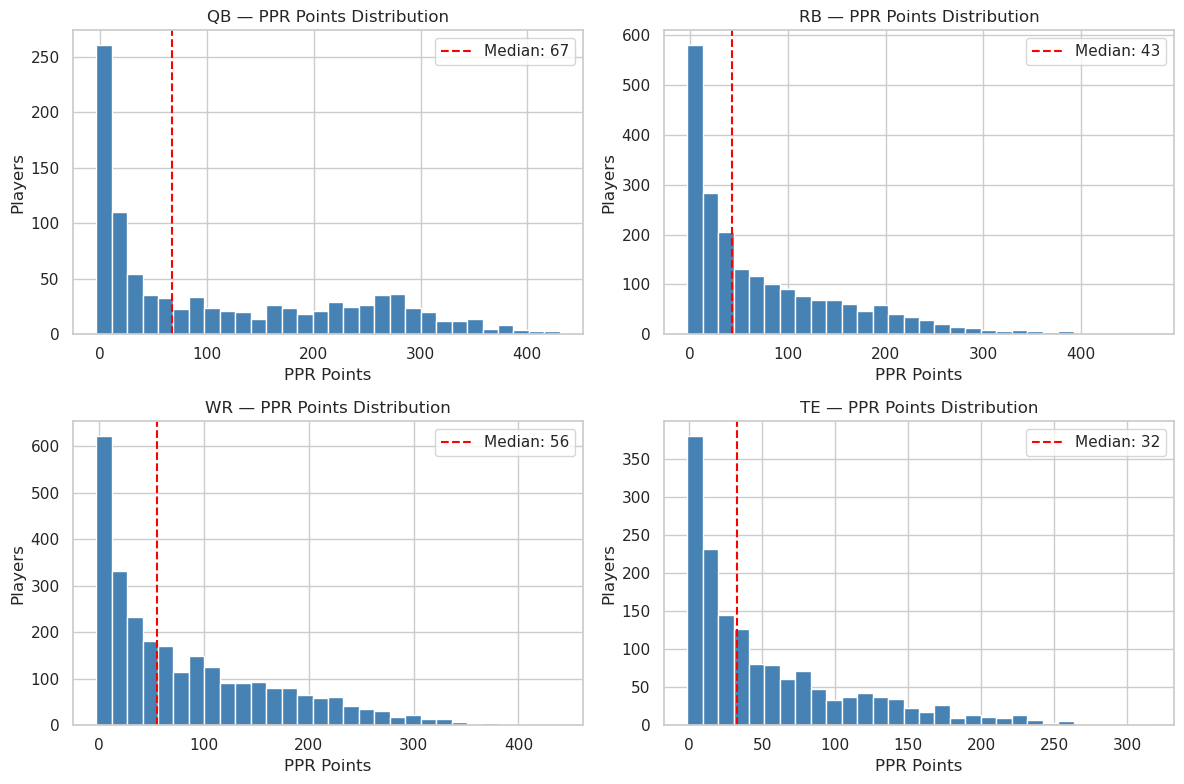

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, pos in zip(axes.flatten(), ['QB', 'RB', 'WR', 'TE']):
    pos_df = df[df['position'] == pos]['fantasy_points_ppr'].dropna()
    ax.hist(pos_df, bins=30, edgecolor='white', color='steelblue')
    ax.set_title(f'{pos} — PPR Points Distribution')
    ax.set_xlabel('PPR Points')
    ax.set_ylabel('Players')
    ax.axvline(pos_df.median(), color='red', linestyle='--', label=f'Median: {pos_df.median():.0f}')
    ax.legend()
plt.tight_layout()
plt.show()

## 3. Age Curves by Position
How does average PPR output change with age per position?

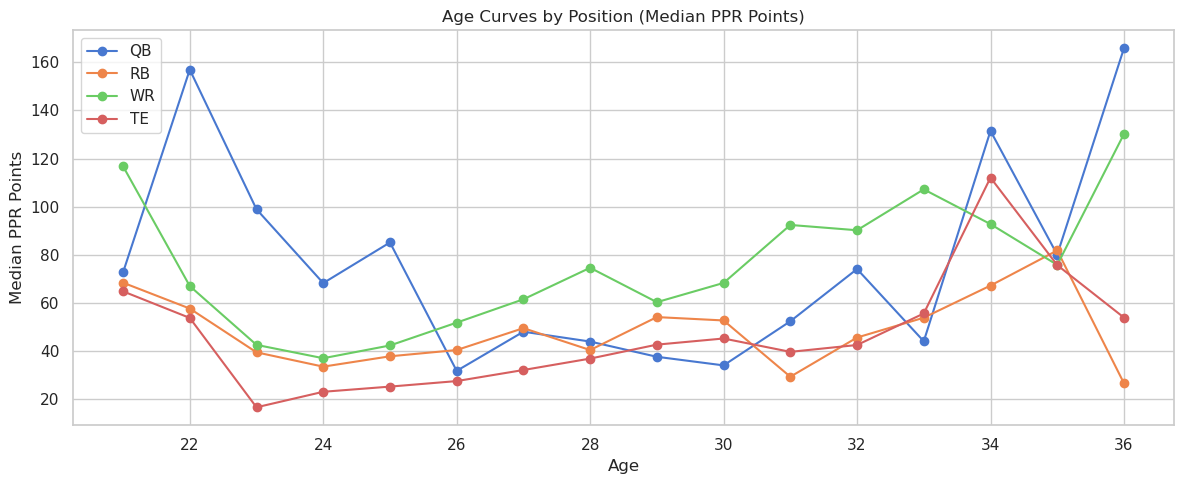

In [6]:
if 'age_at_season' in df.columns:
    age_curve = (
        df.dropna(subset=['age_at_season'])
        .assign(age=lambda x: x['age_at_season'].round().astype(int))
        .groupby(['position', 'age'])['fantasy_points_ppr']
        .median()
        .reset_index()
    )
    fig, ax = plt.subplots(figsize=(12, 5))
    for pos in ['QB', 'RB', 'WR', 'TE']:
        sub = age_curve[(age_curve['position'] == pos) &
                        (age_curve['age'] >= 21) & (age_curve['age'] <= 36)]
        ax.plot(sub['age'], sub['fantasy_points_ppr'], marker='o', label=pos)
    ax.set_xlabel('Age')
    ax.set_ylabel('Median PPR Points')
    ax.set_title('Age Curves by Position (Median PPR Points)')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('age_at_season not available.')

## 4. Year-over-Year PPR Consistency
How well does this year's PPR predict next year's PPR? (Naive baseline check)

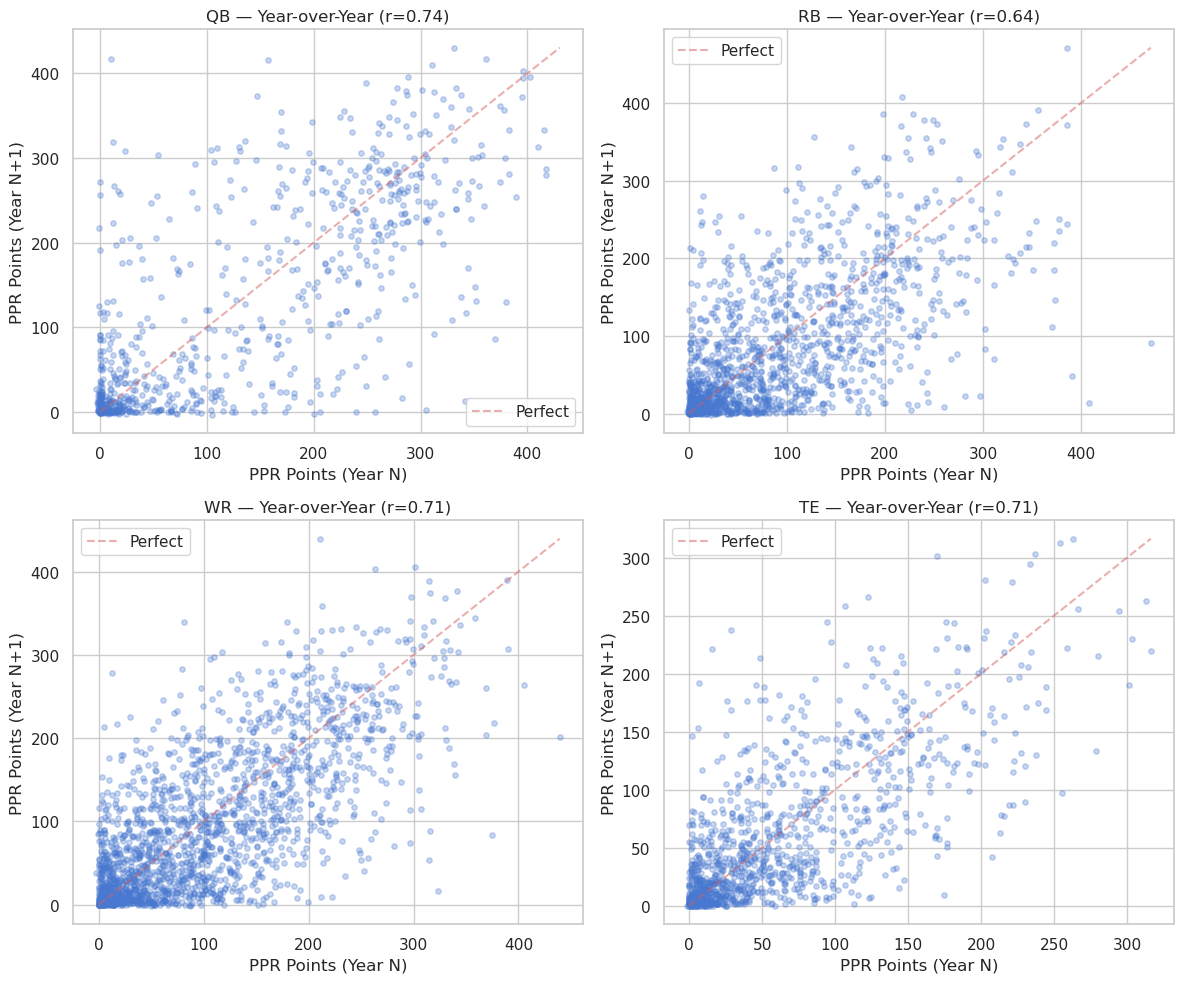

In [7]:
df_sorted = df.sort_values(['player_id', 'season'])
df_sorted['ppr_next'] = df_sorted.groupby('player_id')['fantasy_points_ppr'].shift(-1)
yoy = df_sorted.dropna(subset=['fantasy_points_ppr', 'ppr_next'])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, pos in zip(axes.flatten(), ['QB', 'RB', 'WR', 'TE']):
    sub = yoy[yoy['position'] == pos]
    ax.scatter(sub['fantasy_points_ppr'], sub['ppr_next'], alpha=0.3, s=15)
    corr = sub[['fantasy_points_ppr', 'ppr_next']].corr().iloc[0, 1]
    ax.set_title(f'{pos} — Year-over-Year (r={corr:.2f})')
    ax.set_xlabel('PPR Points (Year N)')
    ax.set_ylabel('PPR Points (Year N+1)')
    lims = [0, max(sub['fantasy_points_ppr'].max(), sub['ppr_next'].max())]
    ax.plot(lims, lims, 'r--', alpha=0.5, label='Perfect')
    ax.legend()
plt.tight_layout()
plt.show()

## 5. Correlation Heatmap (WR Example)

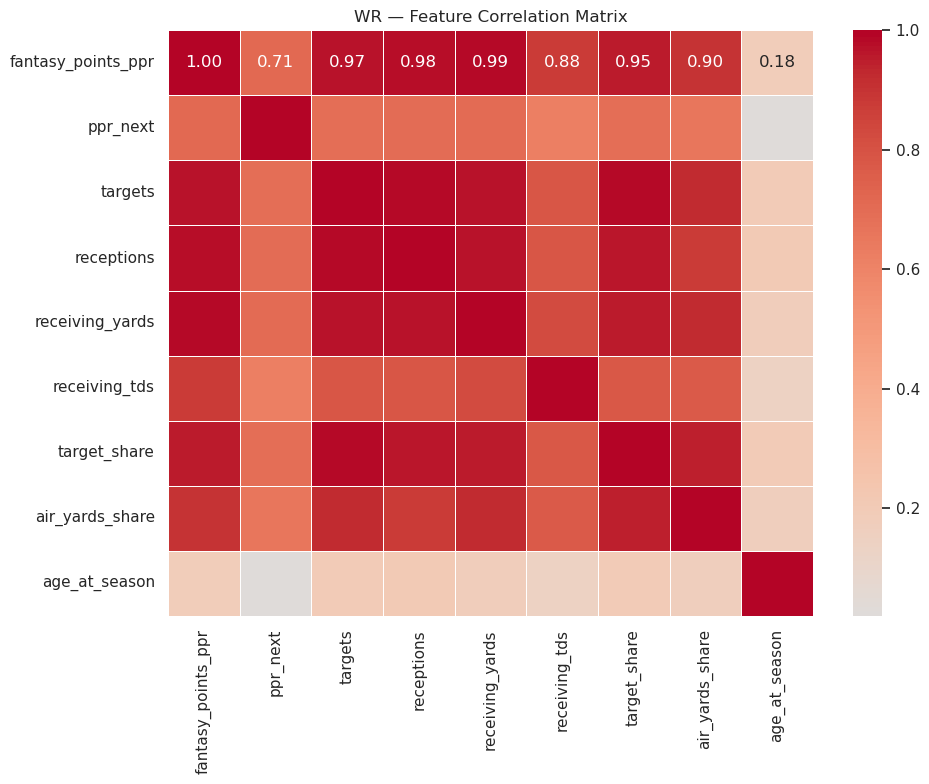

In [8]:
wr = yoy[yoy['position'] == 'WR'].copy()

corr_cols = [
    'fantasy_points_ppr', 'ppr_next', 'targets', 'receptions',
    'receiving_yards', 'receiving_tds', 'target_share',
    'air_yards_share', 'wopr', 'age_at_season',
]
available = [c for c in corr_cols if c in wr.columns]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(wr[available].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('WR — Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 6. Target Share vs Next-Year PPR (WR / TE)

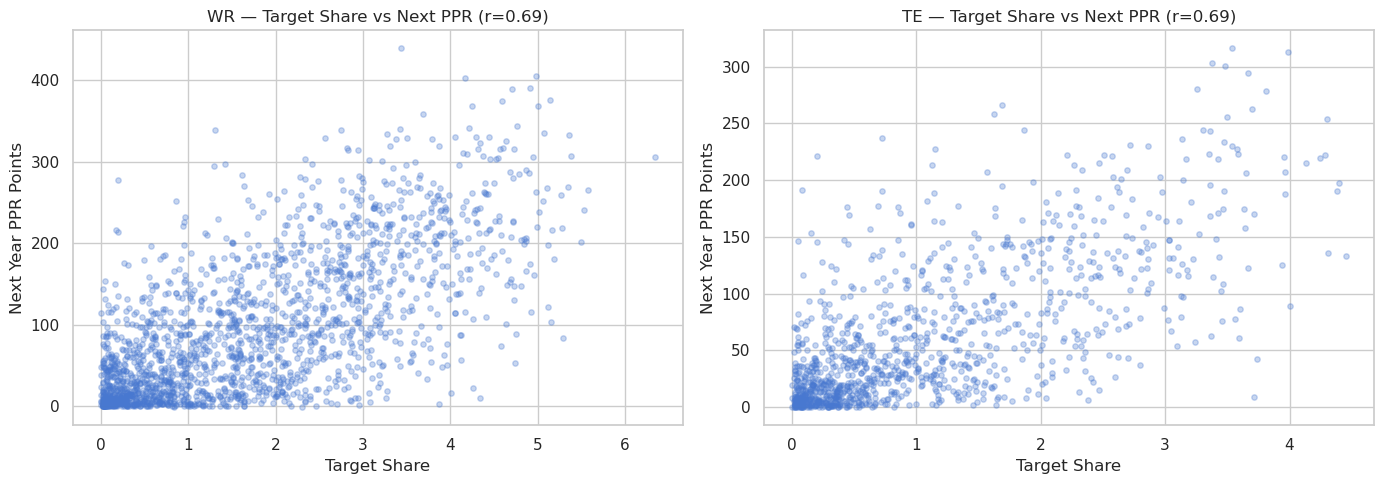

In [9]:
if 'target_share' in yoy.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, pos in zip(axes, ['WR', 'TE']):
        sub = yoy[yoy['position'] == pos].dropna(subset=['target_share'])
        ax.scatter(sub['target_share'], sub['ppr_next'], alpha=0.3, s=15)
        corr = sub[['target_share', 'ppr_next']].corr().iloc[0, 1]
        ax.set_title(f'{pos} — Target Share vs Next PPR (r={corr:.2f})')
        ax.set_xlabel('Target Share')
        ax.set_ylabel('Next Year PPR Points')
    plt.tight_layout()
    plt.show()
else:
    print('target_share not available in dataset.')

## 7. RB Age Cliff

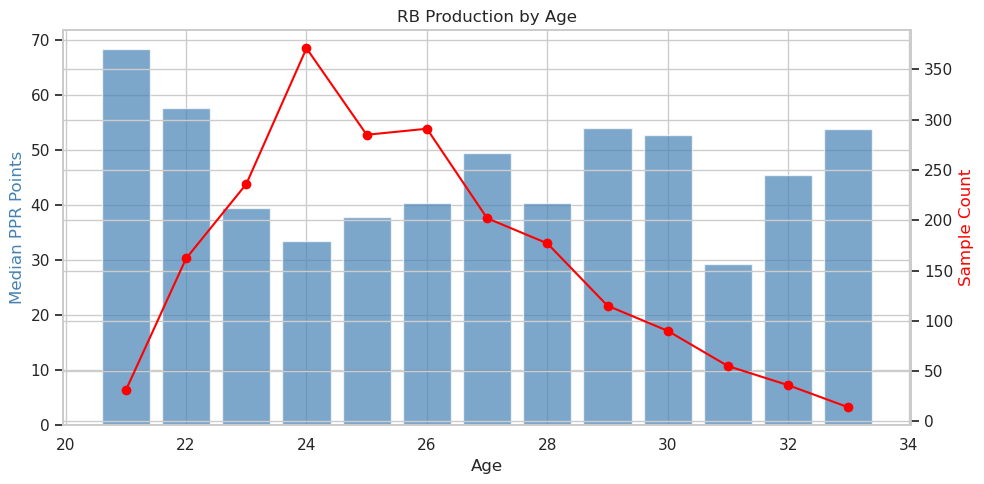

In [10]:
if 'age_at_season' in df.columns:
    rb = df[df['position'] == 'RB'].dropna(subset=['age_at_season']).copy()
    rb['age_bin'] = rb['age_at_season'].round().astype(int)
    rb_age = rb.groupby('age_bin')['fantasy_points_ppr'].agg(['median', 'count']).reset_index()
    rb_age = rb_age[(rb_age['age_bin'] >= 21) & (rb_age['age_bin'] <= 33) & (rb_age['count'] >= 5)]

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()
    ax1.bar(rb_age['age_bin'], rb_age['median'], color='steelblue', alpha=0.7, label='Median PPR')
    ax2.plot(rb_age['age_bin'], rb_age['count'], color='red', marker='o', label='Sample size')
    ax1.set_xlabel('Age')
    ax1.set_ylabel('Median PPR Points', color='steelblue')
    ax2.set_ylabel('Sample Count', color='red')
    ax1.set_title('RB Production by Age')
    plt.tight_layout()
    plt.show()

## 8. Top Players by Season (Sanity Check)

In [11]:
name_col = 'full_name' if 'full_name' in df.columns else 'name'
top_2023 = (
    df[df['season'] == 2023]
    .sort_values('fantasy_points_ppr', ascending=False)
    [[name_col, 'position', 'fantasy_points_ppr', 'target_share', 'age_at_season']]
    .head(20)
)
print('Top 20 PPR scorers in 2023:')
top_2023

Top 20 PPR scorers in 2023:


,full_name,position,fantasy_points_ppr,target_share,age_at_season
7006,CeeDee Lamb,WR,405.20,4.983551,24.4
6881,Josh Allen,QB,394.64,0.000000,27.3
6777,Christian McCaffrey,RB,391.30,2.985537,27.2
6765,Tyreek Hill,WR,376.40,5.282512,29.5
7011,Jalen Hurts,QB,356.82,0.000000,25.1
6767,Dak Prescott,QB,342.84,0.000000,30.1
6871,Lamar Jackson,QB,331.22,0.000000,26.6
7072,Amon-Ra St. Brown,WR,330.90,4.726807,23.9
6986,Jordan Love,QB,319.06,0.000000,24.8
7253,Puka Nacua,WR,298.50,4.870507,22.3
